# 🚀 Makine Öğrenmesi Reboot Challenge 🚀

Airbnb verisiyle uygulamalı deneyimde bilginizi uygulamaya hazır olun.

Üzerinde çalışacağımız konular:

🧹 Veri Temizleme

🚦 Eğitim-Test Bölme

👷 Pipeline'lar ile doğru şekilde ön işleme

📈 Doğrusal Regresyon

🔁 Çapraz Doğrulama

🎯 İnce Ayar

Hadi başlayıp bu kavramları hayata geçirelim! 🏊‍♀️🏊‍♂️

## 1. Veriyi anlayın 👏 ve temel temizlik 🧹

Bu challenge'da gerçek Airbnb verisi kullanacağız. Bu veri birçok şehirden geliyor. Kodlarımızı yeniden kullanılabilir yapmak isteyeceğiz. Bu şekilde farklı CSV dosyalarıyla hızlı bir şekilde çalışabiliriz, çünkü her CSV için yeni kod yazmamız gerekmeyecek!

### Veriyi yükleme

Öncelikle: ***Asheville, Kuzey Karolina***. CSV dosyası burada mevcut: [🔗 link 🔗](https://d32aokrjazspmn.cloudfront.net/materials/asheville_airbnb.csv).

Sahip olduğumuz tüm bilgilere dayanarak Airbnb konaklama yerinin fiyatını tahmin etmek için doğrusal regresyon kullanacağız!

👉 İlk olarak, CSV dosyasını `df` adlı bir DataFrame'e yükleyelim.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

CSV'deki ilk (isimsiz) sütun aslında bir indeks sütunu. Bu Pandas'ın varsayılan olarak oluşturduğu indeks, ancak zaten bir indeksimiz olduğu için pek faydalı değil!
    
Bundan kurtulmak için, ya `.reset_index()` metodunu kullan, ya da - **daha kolay!** - CSV dosyasını okurken `index_col=0` kullan.

index_col=0'ın ne yaptığını düşünün. Mevcut indeksimiz 3. sütunda olsaydı `index_col` kullanabilir miydik?
</details>

In [1]:
import pandas as pd

url = "https://d32aokrjazspmn.cloudfront.net/materials/asheville_airbnb.csv"

df = pd.read_csv(url, index_col=0)
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,...,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,120.0,...,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,100.0,...,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,66.0,...,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,33.0,...,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,45.0,...,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."


👉 DataFrame'inizin dtypes'larını inceleyin. Bir şeyler yanlış. Görüyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

`price` sütunu bir object, float değil.

</details>

👉 Tanımladığınız sütunu temizleyin.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

[`.str.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) ve [`.astype()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html) metodlarına ihtiyacınız olacak. 
</details>

In [2]:
print(df['price'].dtype)
print(df.shape)

float64
(2856, 21)


#### Kodunuzu kontrol edin

In [3]:
from nbresult import ChallengeResult

result = ChallengeResult('df',
    df_columns=df.columns,
    price_dtype=df['price'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 2 items

test_df.py::TestDf::test_df_has_no_double_index_column PASSED            [ 50%]
test_df.py::TestDf::test_price_has_the_right_dtype PASSED                [100%]

============================== 2 passed in 0.99s ===============================


💯 You can commit your code:

git add tests/df.pickle

git commit -m 'Completed df step'

git push origin master



### Hedef dağılımı

👉 Hedefin dağılımına bir göz atın. Ayrıca minimum ve maksimum değerlerini de kontrol edin.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

Bir pd.Series'in `.hist()` metodunu kullanın. Bunu hedef sütununuza uygulayabilirsiniz. 
</details>

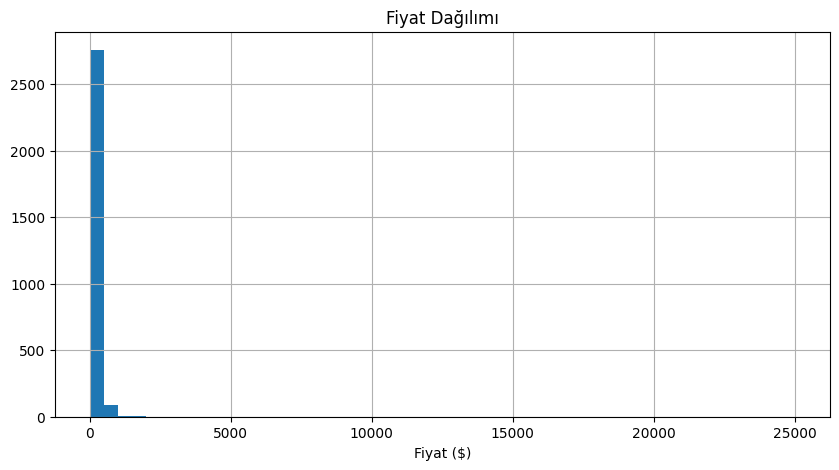

Min: 19.0, Max: 24999.0


In [4]:
df['price'].hist(bins=50, figsize=(10, 5))
import matplotlib.pyplot as plt
plt.title("Fiyat Dağılımı")
plt.xlabel("Fiyat ($)")
plt.show()
print(f"Min: {df['price'].min()}, Max: {df['price'].max()}")

Oldukça çarpık görünüyor! 50 ile 1500 dolar arasında (ikisi de dahil) fiyatlandırılmış Airbnb ilanlarına odaklanacağız.

👉 Sadece 50 ile 1500 arasında fiyatlandırılmış ilanları içeren `reduced` adlı bir DataFrame oluşturun.

In [5]:
reduced = df[(df['price'] >= 50) & (df['price'] <= 1500)].copy()
print(f"reduced shape: {reduced.shape}")

reduced shape: (2766, 21)


#### Kodunuzu kontrol edin

In [6]:
from nbresult import ChallengeResult

result = ChallengeResult('reduced',
    reduced_min=reduced['price'].min(),
    reduced_max=reduced['price'].max(),
    reduced_shape=reduced.shape
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 2 items

test_reduced.py::TestReduced::test_reduced_has_the_right_shape PASSED    [ 50%]
test_reduced.py::TestReduced::test_reduced_min_max PASSED                [100%]

============================== 2 passed in 0.43s ===============================


💯 You can commit your code:

git add tests/reduced.pickle

git commit -m 'Completed reduced step'

git push origin master



### Diğer sütunları temizleyin

👉 `reduced` DataFrame'inizi inceleyin. 

Modellemimize başlamadan önce biraz değiştirmemiz gereken iki sütun var. Hangilerinin olduğunu ve neden olduğunu görüyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- `bathrooms_text` sütunu çoğunlukla sayısal bilgiye sahip görünüyor, ancak metin formatında.
- `instant_bookable` sütununda `t` ve `f` değerleri var. Bunun yerine sadece 1'ler ve 0'lar olsa bizim için daha kolay olurdu.
</details>

İlk problemli sütunla başlayalım. 

👉 Sütundaki benzersiz değerlere bir göz atın.

In [7]:
print(reduced['bathrooms_text'].unique())

<StringArray>
[          '1 bath', '2.5 shared baths',    '1 shared bath',
        '1.5 baths',   '1 private bath',        '2.5 baths',
          '2 baths',   '2 shared baths',        '3.5 baths',
          '3 baths', '1.5 shared baths',          '4 baths',
   '0 shared baths',        '4.5 baths',          '0 baths',
          '5 baths',        'Half-bath',          '7 baths',
          '6 baths',        '5.5 baths']
Length: 20, dtype: str


İşte temizlik fonksiyonu (sizin için küçük bir 🎁), ancak bunu DataFrame'e kendiniz _uygulamanız_ gerekecek.

In [8]:
def extract_number(text):
    if text.lower() == "half-bath":
        return 0.5
    else:
        return float(text.split(' ')[0])

👉 Sütunu temizlemek için fonksiyonu kullanın ve sonucu aynı sütuna geri kaydedin.

In [9]:
reduced['bathrooms_text'] = reduced['bathrooms_text'].dropna().apply(extract_number)
reduced['bathrooms_text'] = reduced['bathrooms_text'].fillna(1.0)
print(reduced['bathrooms_text'].dtype)

float64


Şimdi diğer sütun üzerinde çalışalım. Değerleri 0'lar ve 1'lere dönüştürmenin birden fazla yolu var. 

👉 Rahat ettiğiniz bir yöntemi seçin (for döngüsü olmadığı sürece...) ve sütunu temizlemek için kullanın.
<br><br>
<details><summary><i>💡  İpucu</i></summary>
    
- [`pandas.Series.map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) ile bir eşleme sözlüğü
- [`pandas.Series.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) ile lambda fonksiyonu (büyük veri setlerinde yavaş olduğu için önerilmez)
- [`numpy.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html)
- Boolean indexing
</details>

In [10]:
reduced['instant_bookable'] = reduced['instant_bookable'].map({'t': 1, 'f': 0}).astype('int64')
print(reduced['instant_bookable'].value_counts())

instant_bookable
1    1606
0    1160
Name: count, dtype: int64


#### Kodunuzu kontrol edin

In [11]:
from nbresult import ChallengeResult

result = ChallengeResult('cleaned',
    reduced_shape=reduced.shape,
    bathrooms_text_dtype=reduced['bathrooms_text'].dtype,
    instant_bookable_dtype=reduced['instant_bookable'].dtype,

)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 3 items

test_cleaned.py::TestCleaned::test_bathrooms_text_dtype PASSED           [ 33%]
test_cleaned.py::TestCleaned::test_cleaned_has_the_right_shape PASSED    [ 66%]
test_cleaned.py::TestCleaned::test_instant_bookable_dtype PASSED         [100%]

============================== 3 passed in 0.65s ===============================


💯 You can commit your code:

git add tests/cleaned.pickle

git commit -m 'Completed cleaned step'

git push origin master



### Yeniden kullanılabilir bir fonksiyon yapın

Harika! Tüm temizliği yaptık. Peki ya daha sonra bunu başka bir CSV dosyası için yapmak istersek?

👉 Önceki tüm adımları birleştiren bir `df_load_and_clean` fonksiyonu oluşturun. Her şey yolunda giderse, daha önce yaptıklarınızdan sadece kopyala-yapıştır yapmanız yeterli olacak.

In [12]:
def df_load_and_clean(url):
    '''Loads a CSV from the `url` provided and does the basic cleaning'''
   
    df = pd.read_csv(url, index_col=0)

    df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

    df = df[(df['price'] >= 50) & (df['price'] <= 1500)].copy()

    df['bathrooms_text'] = df['bathrooms_text'].dropna().apply(extract_number)
    df['bathrooms_text'] = df['bathrooms_text'].fillna(1.0)

    df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0}).astype('int64')

    return df

#### Kodunuzu kontrol edin

In [13]:
new_df = df_load_and_clean(url)

In [14]:
from nbresult import ChallengeResult

result = ChallengeResult('load_and_clean',
    new_df=new_df,
    new_shape=new_df.shape,
    price_dtype=new_df['price'].dtype,
    bathrooms_text_dtype=new_df['bathrooms_text'].dtype,
    instant_bookable_dtype=new_df['instant_bookable'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 5 items

test_load_and_clean.py::TestLoadAndClean::test_bathrooms_text_dtype PASSED [ 20%]
test_load_and_clean.py::TestLoadAndClean::test_cleaned_has_the_right_shape PASSED [ 40%]
test_load_and_clean.py::TestLoadAndClean::test_instant_bookable_dtype PASSED [ 60%]
test_load_and_clean.py::TestLoadAndClean::test_price_has_the_right_dtype PASSED [ 80%]
test_load_and_clean.py::TestLoadAndClean::test_return PASSED             [100%]

============================== 5 passed in 1.07s ===============================


💯 You can commit your code:

git add tests/load_and_clean.pickle

git commit -m 'Completed load_and_clean step'

git push origin master



Harika! Artık sizin için veriyi yükleyen ve temizliği yapan bir fonksiyonunuz var. Bir sonraki adıma geçme zamanı!

## 2. Eğitim-Test Bölme 🚦

### İlgili sütunları seçin

Sütunlara bakın ve sadece doğrusal regresyon görevimizde bize yardımcı olabilecekleri seçin. 

İpucu: bazı sütunlar regresyon görevimiz için gerçekten katma değer sağlamayacak. Bunları çıkarın.

👉 `new_df`'den başlayarak `X` ve `y` oluşturun

In [15]:
drop_cols = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name',
             'description', 'price']

X = new_df.drop(columns=[c for c in drop_cols if c in new_df.columns])
y = new_df['price']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X columns: {X.columns.tolist()}")

X shape: (2766, 14)
y shape: (2766,)
X columns: ['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'instant_bookable']


#### Kodunuzu kontrol edin

In [16]:
from nbresult import ChallengeResult

result = ChallengeResult('x_and_y',
    x_shape=X.shape,
    y_shape=y.shape,
    x_columns=X.columns
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 4 items

test_x_and_y.py::TestXAndY::test_excluded_columns PASSED                 [ 25%]
test_x_and_y.py::TestXAndY::test_target_not_in_x PASSED                  [ 50%]
test_x_and_y.py::TestXAndY::test_x_has_the_right_shape PASSED            [ 75%]
test_x_and_y.py::TestXAndY::test_y_has_the_right_shape PASSED            [100%]

============================== 4 passed in 1.35s ===============================


💯 You can commit your code:

git add tests/x_and_y.pickle

git commit -m 'Completed x_and_y step'

git push origin master



### Eğitim ve test setine bölün

👉 Verinizi eğitim ve test setine bölün.

80/20 bölmesi yapalım.

Ve `42` random state kullanalım. (Son pipeline'ınızda random state'i kaldırmak istersiniz, ama burada sonuçlarımızı karşılaştırmamıza yardımcı olacak.)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (2212, 14), X_test: (554, 14)


## 3. Ön İşleme 👷

Zaten biraz temel temizlik yaptık, ama bazı ön işleme adımlarına ihtiyacımız olacak. Bunları `scikit-learn` kullanarak yapalım. Ön işlemeyi hemen pipeline'lar kullanarak yapacağız.

❓ Neden pipeline'lar kullanmak istiyoruz?

<details>
  <summary><i>Cevap</i>
  </summary>

  1. Ön işleme adımlarımızı güzelce yapılandırmamızı sağlarlar
  2. Ön işleme adımlarımızı eğitim setine fit etmeyi ve eğitim setini, test setini ve modelimize beslemek istediğimiz yeni verileri dönüştürmeyi kolaylaştırırlar
  3. Ön işleme ve model içeren tam bir pipeline'ı düzgün bir şekilde çapraz doğrulama ve grid search yapmamızı sağlayacaklar

</details>

Varsayılan olarak preprocessor'lar NumPy dizileri çıktı verir. Çalışması daha kolay olduğu için Pandas DataFrame'leri çıktı vermeyi tercih ediyoruz.

Numpy dizisi yerine DataFrame formatında çıktı tutmak için transformer'ınızın `.set_output(transform='pandas')` metodunu kullanabilirsiniz.

💡 Ama bunu her transformer için yapmak yerine, bunu global olarak da ayarlayabilirsiniz. Aşağıdaki hücreyi çalıştırın.

In [18]:
from sklearn import set_config
set_config(transform_output="pandas")

### Sayısal özellikler

👉 Sayısal özelliklerle bir liste oluşturun

In [19]:
# İpucu: sütunlarınızı yazdırın ve sonra yeni listenizi oluşturmak için kopyala-yapıştır yapın
# Bir listeden sütun çıkarmak yazmaktan (ve yazım hatalarını düzeltmekten) daha kolay
X_train.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable'],
      dtype='str')

In [23]:
num_cols = [
    'latitude', 'longitude', 'accommodates', 'bathrooms_text',
    'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'availability_365'
]
print(f"num_cols sayısı: {len(num_cols)}")

num_cols sayısı: 10


#### Eksik değerler

👉 Eksik değerleri inceleyin. Kaç sütunda eksik değer var? Kaç değer eksik?

In [25]:
print(X_train[num_cols].isnull().sum()[X_train[num_cols].isnull().sum() > 0])

bedrooms                116
beds                     16
review_scores_rating    147
dtype: int64


Bu eksik değerlerle ilgili bir şeyler yapmamız gerekecek. Hangi stratejileri uygulayabilirsiniz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- Eksik değerli sütunları **silin**, ama sadece küçük bir yüzdede eksik değerimiz var. O yüzden bunu yapmayalım.
- Eksik değerli satırları **silin**. Hızlı ve basit, ama çoğu sütun için aslında değerlerimiz var. O yüzden bunu yapmayalım.
- **Eksik değerleri impute edin**: boşlukları doldurun.
</details>

Eksik değerli sütunlara bakın. Her biri için en iyi imputation stratejisi ne olurdu? Kararınızı vermek için her sütunun benzersiz değerlerini kontrol edin.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- `bedrooms`: eğer veri yoksa, ayrı bir yatak odası olmadığını varsayabiliriz. Yani 0'larla impute edin.
- `beds`: eğer veri yoksa, yatak olmadığını varsayabiliriz. Yani 0'larla impute edin.
- `review_scores_rating`: eğer veri yoksa, henüz bir rating olmadığını varsayabiliriz ve ortalama rating ile impute edebiliriz. (Bu durumda diğer stratejiler için de argüman sunabilirsiniz. Bir [`KNNImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) burada ilginç olabilir, ama şimdilik basit imputation stratejimize bağlı kalacağız.)
</details>

In [26]:
X_train.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable
2198,28806,35.575588,-82.575706,Entire rental unit,Entire home/apt,4,1.0,2.0,2.0,3,43,4.98,36,0
2804,28806,35.569290,-82.612050,Entire home,Entire home/apt,6,2.0,4.0,5.0,30,0,NaN,45,0
2307,28806,35.592520,-82.612850,Entire home,Entire home/apt,5,1.5,3.0,3.0,30,0,NaN,325,1
273,28715,35.514620,-82.650800,Entire cottage,Entire home/apt,7,1.0,3.0,3.0,1,529,4.72,192,1
2132,28715,35.554130,-82.650110,Private room in home,Private room,3,1.0,1.0,1.0,1,109,4.97,147,1


👉 Imputer'larımızı hazırlayalım.

İki farklı stratejimiz olduğu için iki ayrı imputer'a ihtiyacınız olacak: biri 0 imputation için, diğeri ortalama imputation için!

Bunları `zero_imputer` ve `mean_imputer` olarak adlandırın.

In [27]:
from sklearn.impute import SimpleImputer

In [28]:
zero_imputer = SimpleImputer(strategy='constant', fill_value=0)
mean_imputer = SimpleImputer(strategy='mean')

zero_imputer_cols = ['bedrooms', 'beds']
mean_imputer_cols = ['review_scores_rating']

Şimdi iki imputer'ımızı pipeline'ımızdaki ilk adım olarak bir column transformer'da birleştirebiliriz.

👉 Şunları yapmak için `num_imputer` adlı bir column transformer yapın :
- yukarıda tanımladığımız sütunlarda sıfır impute edin
- diğer tüm sütunları değişmeden ortalama impute edin (ipucu: `remainder` parametresini düşünün)

(Diğer sütunlarda eksik değer yoktu, ama pipeline'ımızı diğer şehirler için de kullanabiliriz. Bu yüzden şimdilik diğer tüm sütunları ortalama impute edeceğiz.)

Sınıf tabanlı yaklaşım (`Pipeline`, `ColumnTransformer`) veya `make_pipeline`, `make_column_transformer` kısayol fonksiyonları arasında seçim yapabilirsiniz.

In [29]:
from sklearn.compose import ColumnTransformer, make_column_transformer

num_imputer = ColumnTransformer([
    ('zero', zero_imputer, zero_imputer_cols),
    ('mean', mean_imputer, mean_imputer_cols),
], remainder='passthrough')

num_imputer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('zero', ...), ('mean', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

#### Sayısal özellikleri ölçekleyin

👉 Hangi sütunları ölçeklendirmeniz gerekiyor?

Ayrıca hangi scaler'ı seçeceğinizi görmek için dağılımları kontrol edin. 👉 Aşağıdaki hücreyi çalıştırın.

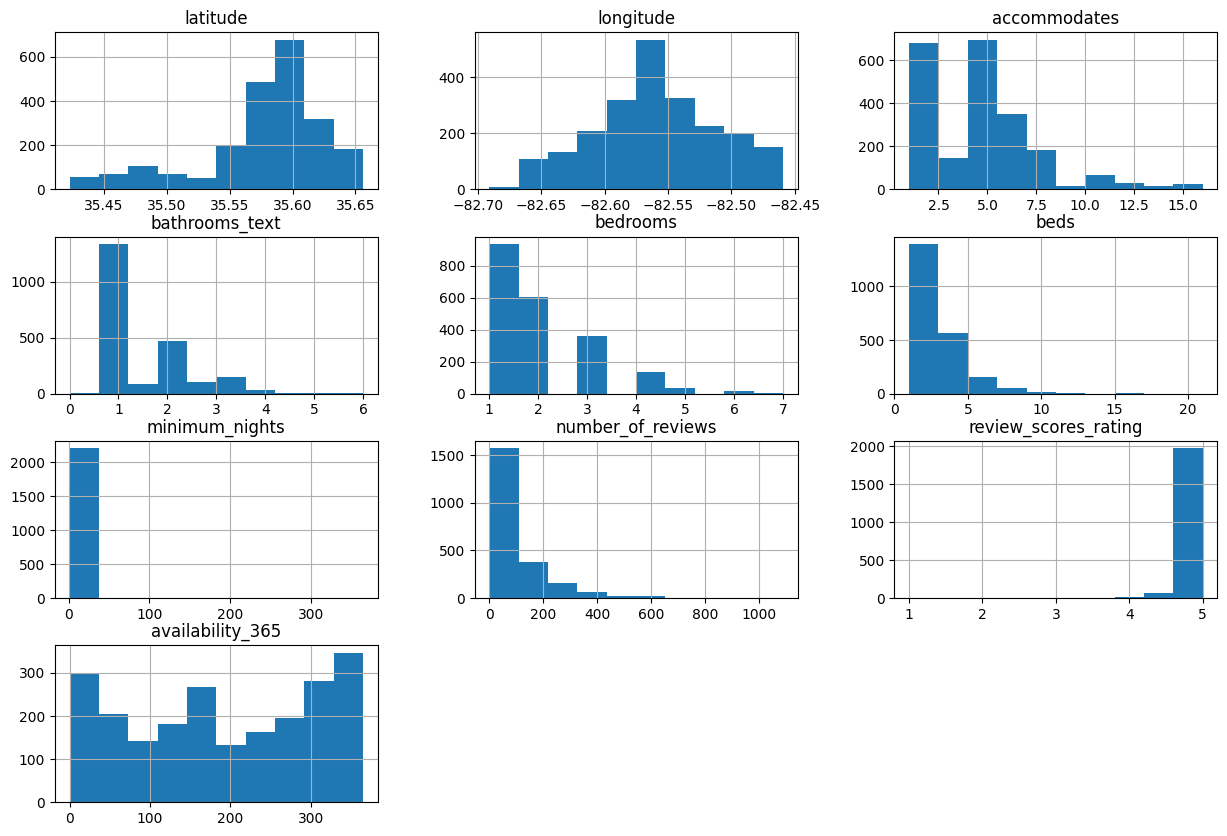

In [30]:
X_train[num_cols].hist(figsize=(15,10));

👉 Uygun bir scaler başlatın. Şimdilik hızlı gitmek için seçtiğimiz tüm sütunları RobustScaler ile ölçeklendireceğiz. Daha sonra bu adıma geri dönmeli ve her sütun için en uygun scaler'ı seçmeliyiz.

In [31]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.set_output(transform='pandas')

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


Sayısal özelliklerimiz için bir imputer ve bir scaler oluşturduk. Artık her iki adımı da birleştirmek için bir pipeline oluşturabiliriz.

👉 Şunları yapmak için `num_pipe` adlı bir pipeline yapın :
- `num_imputer`ımızı kullanarak eksik değerleri impute edin
- `scaler`ımızı kullanarak özellikleri ölçekleyin

Sınıf tabanlı yaklaşım (`Pipeline`, `ColumnTransformer`) veya `make_pipeline`, `make_column_transformer` kısayol fonksiyonları arasında seçim yapabilirsiniz.

In [32]:
from sklearn.pipeline import Pipeline, make_pipeline

num_pipe = make_pipeline(num_imputer, scaler)
num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('robustscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('zero', ...), ('mean', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: flo

#### Kodunuzu kontrol edin

In [33]:
from nbresult import ChallengeResult

result = ChallengeResult('scaler',
    num_cols=num_cols,
    X_train_scaled=num_pipe.fit_transform(X_train[num_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 2 items

test_scaler.py::TestScaler::test_columns_numeric PASSED                  [ 50%]
test_scaler.py::TestScaler::test_has_the_right_shape PASSED              [100%]

============================== 2 passed in 1.46s ===============================


💯 You can commit your code:

git add tests/scaler.pickle

git commit -m 'Completed scaler step'

git push origin master



### Kategorik özellikleri One Hot Encode edin

👉 Hangi sütunları encode etmeniz gerekiyor?

In [34]:
cat_cols = ['neighbourhood_cleansed', 'room_type', 'property_type', 'instant_bookable']
print(f"cat_cols: {cat_cols}")

cat_cols: ['neighbourhood_cleansed', 'room_type', 'property_type', 'instant_bookable']


İyi uygulama: her sütunda kaç farklı değeriniz olduğunu kontrol edin.

👉 Bir göz atmak için aşağıdaki hücreyi çalıştırın.

Her değerin encoding'den sonra X'imizdeki bir sütun haline geleceğini unutmayın.

In [35]:
for col in cat_cols:
    display(pd.DataFrame(X_train[col].value_counts()))

,count
neighbourhood_cleansed,
28806,618
28801,511
28804,306
28803,296
28805,210
28704,152
28715,64
28732,55


,count
room_type,
Entire home/apt,1934
Private room,267
Hotel room,10
Shared room,1


,count
property_type,
Entire home,732
Entire rental unit,292
Entire guest suite,283
Private room in home,157
Entire condo,137
Entire cabin,87
Entire cottage,86
Entire guesthouse,81
Entire bungalow,64


,count
instant_bookable,
1,1289
0,923


Bu sütunlardan biri için encoding yaparken biraz akıllı olmamız gerekeceği açık. Yoksa son sonuçta çok fazla sütunumuz olacak.

👉 Oluşturulan sütun sayısını sınırlamak için OneHotEncoder için doğru parametreyi bulun.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
İki aday var:
<ul>
    <li><strong>max_categories</strong>
    </li>
    <li><strong>min_frequency</strong>
    </li>
</ul>
    İlk iterasyonumuz için <code>max_categories=10</code> kullanalım. Bunu daha sonra değiştirebiliriz.
</details>

👉 Şimdi kategorik özellikleriniz için bir one hot encoder oluşturun

In [38]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    max_categories=10,
    drop='if_binary',
    handle_unknown='ignore',
    sparse_output=False
)
encoder.set_output(transform='pandas')

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'if_binary'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output features for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",10
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number typ

Kategorik özelliklerimiz için bir OneHotEncoder oluşturduk.

Kategorik özelliklerimizde eksik değer olmadığı için bizim durumumuzda bu yeterliydi. Ama unutmayın: pipeline'ımızı diğer şehirler için de kullanabiliriz. Bu yüzden eksik değerler için bir imputer eklemek daha iyi.

👉 Şunları yapmak için `cat_pipe` adlı bir pipeline yapın :
- en sık değerle eksik değerleri impute edin
- `scaler`ımızı kullanarak özellikleri ölçekleyin

`num_pipe`'ınızda kullandığınızdan farklı bir yaklaşım kullanın (sınıf tabanlı vs kısayol fonksiyonu)

In [44]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    encoder
)
cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('onehotencoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive es

#### Kodunuzu kontrol edin

In [45]:
from nbresult import ChallengeResult

result = ChallengeResult('encoder',
    cat_cols=cat_cols,
    X_train_encoded=cat_pipe.fit_transform(X_train[cat_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 2 items

test_encoder.py::TestEncoder::test_columns_categorical PASSED            [ 50%]
test_encoder.py::TestEncoder::test_has_the_right_shape PASSED            [100%]

============================== 2 passed in 0.91s ===============================


💯 You can commit your code:

git add tests/encoder.pickle

git commit -m 'Completed encoder step'

git push origin master



### Sayısal ve kategorik özellikleri tekrar bir araya getirme

Sayısal için bir pipeline'ımız ve kategorik özellikler için bir one-hot-encoder'ımız var. Bunları bir araya getirelim.

👉 Sayısal özellikleri `num_pipe`'ımızdan, kategorik özellikleri `cat_pipe`'ımızdan geçirecek `preprocessor` adlı yeni bir column transformer yapın.

Eğer önceki adımda sınıf tabanlı yaklaşımı (`Pipeline`, `ColumnTransformer`) kullandıysanız, bu sefer `make_pipeline`, `make_column_transformer` kısayol fonksiyonlarına geçin. Ya da tam tersini yapın. Sadece değiştirdiğinizden emin olun 🙃

In [43]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
], remainder='drop')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

Sınıf tabanlı yaklaşım ile `make_***` kısayol fonksiyonları arasındaki farkı görüyor musunuz? 

Sınıf tabanlı yaklaşım farklı adımlar için güzel isimler tanımlamanızı sağlar. Eğer `make_***` kullanırsanız, scikit-learn sizin için ismi belirleyecek. Bu özellikle `ColumnTransformer` kullanırken daha görünür hale gelir.

Ne yaptığımızı özetleyelim:


- **Sayısal** sütunlar için (`num_cols`'umuz):
  - İlk olarak, imputer'larımızı kullanarak eksik değerleri impute ettik:
    - `bedrooms` ve `beds` özellikleri için `zero_imputer`
    - `review_scores_rating` özelliği için `mean_imputer`
    - Diğer sütunlarda eksik değer yoktu, ama preprocessor'ımızı diğer şehirler için de kullanacağımız için hepsini `mean_imputer`'dan da geçirdik
  - İkinci olarak, tüm sayısal özellikleri `scaler`'ımızla ölçeklendirdik
  
  
-  **Kategorik** sütunlar için (`cat_cols`'umuz):
   - Eksik değerleri impute edin. Verilerimizde hiç yoktu, ama yine diğer şehirler için de çalışmasını istiyoruz. En sık değeri impute ediyoruz.
   - `encoder`'ımızla encode edin
  
Pipeline'ımızın nasıl göründüğünün görsel özeti:

<img alt="Pipeline schema" src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/ml-reboot-pipeline.png" width=700>

Eğitim ve test setlerimizi ön işleme tabi tutmak için pipeline'ımızı kullanalım.

Bunları X_train_preprocessed ve X_test_preprocessed'de saklayın.

Muhtemelen birkaç hatayla karşılaşacaksınız. Büyük ihtimalle OneHotEncoder'dan geliyorlar. OneHotEncode'unuz için doğru parametreleri bulup yukarıda değiştirmek size kalmış.

In [46]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
X_train_preprocessed.shape, X_test_preprocessed.shape

/home/arzu/.local/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


((2212, 33), (554, 33))

Test setini ön işleme tabi tutarken bilinmeyen kategoriler hakkında UserWarning alırsanız: bu normaldir. Nedenini biliyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    OneHotEncoder'ımızı hatırlıyor musunuz?
    <br>
    Eğitim setindeki tüm kategorileri 1'ler ve 0'lar içeren sütunlar halinde encode eder.
    <br>
    Encoder'ın test setinde fit sırasında görmediği kategorilerle karşılaşması mümkün. Bu satırlar için tüm encode edilmiş sütunlar 0 içerecek (çünkü <code>handle_unknown='ignore'</code> seçtik).
</details>

#### Kodunuzu kontrol edin

In [47]:
from nbresult import ChallengeResult

result = ChallengeResult('pipeline',
    X_train_preprocessed=X_train_preprocessed,
    X_test_preprocessed=X_test_preprocessed,
    X_train_to_test_pipeline=preprocessor.fit_transform(X_train),
    X_test_to_test_pipeline_not_fitted_on_test=preprocessor.transform(X_test),
)
result.write()

print(result.check())

/home/arzu/.local/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 3 items

test_pipeline.py::TestPipeline::test_has_the_right_shape PASSED          [ 33%]
test_pipeline.py::TestPipeline::test_test_was_only_transformed PASSED    [ 66%]
test_pipeline.py::TestPipeline::test_train_was_transformed PASSED        [100%]

============================== 3 passed in 1.03s ===============================


💯 You can commit your code:

git add tests/pipeline.pickle

git commit -m 'Completed pipeline step'

git push origin master



🚀 Tebrikler! Tam ön işleme pipeline'ınızı oluşturdunuz.

## 4. Modelleme 📈

Artık verimizi ön işleme tabi tutacak bir pipeline'ımız olduğuna göre, sonunda modellemmeye geçebiliriz.

Bir sonraki aşamada 🎯 oynayabileceğimiz bazı parametreler verecek [`ElasticNet`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) doğrusal regresyon modelini kullanacağız. 

ElasticNet modelinin ne olduğunu hatırlıyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    ElasticNet, L1 ve L2 regularization karışımına sahip bir doğrusal regresyon. Temel olarak Ridge ve Lasso regressionı birleştirir.
</details>

👉 Bir ElasticNet modeli başlatın ve `elastic` olarak adlandırın

In [48]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()

Şimdi çapraz doğrulanmış bir skor elde etmek istiyoruz.

Aşağıdaki hücreye bir göz atın ve hücreyi çalıştırın.

In [49]:
from sklearn.model_selection import cross_val_score

cv_results = cross_val_score(elastic, X_train_preprocessed, y_train, cv=5)
cv_results.mean()

np.float64(0.5109832517709864)

**Ama bir şeyi yanlış yaptık! 😱**

👉 Daha fazla okumadan önce yukarıdaki hücrede nerede hata yaptığımızı düşünmek için bir dakika ayırın.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
Çapraz doğrulama yaptığımızda, sadece modelleme adımını çapraz doğruladık.

Çapraz doğrulamada eğitim setimiz yeniden bir eğitim ve doğrulama setine bölünür (ve bizim durumumuzda bu 5 kez olur).

Ama ön işleme adımlarımız bu ikinci bölmeden **önce** tüm eğitim setine uygulandı. 
    
Bu, çapraz doğrulama içindeki eğitim ve doğrulama setimiz arasında veri sızıntısı olduğu anlamına gelir.

İdeal olarak, çapraz doğrulamamızın her katı için şunları yapmak istiyoruz:

  - Tüm ön işleme adımlarını eğitim setine fit et
  - Eğitim ve doğrulama setini dönüştür
  - Modeli eğitimde eğit
  - Doğrulama setinde skor al

Şimdiye kadar yaptığımız çapraz doğrulama, ön işlemeyi doğru bir şekilde yapmadı.
</details>

👉 Bunu nasıl çözebiliriz? Bir dakika düşünün.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
Tüm ön işleme adımlarımız + modelimizle bir pipeline yapıp, sadece modelin yerine bu tam pipeline'ı çapraz doğrulayabiliriz.
    
Bu şekilde çapraz doğrulama her seferinde preprocessor ve modeli sadece eğitim setine fit edecek.
</details>

👉 `preprocessing` pipeline'ınızı `elastic` modelle birleştirerek bir `elastic_pipe` oluşturun

In [50]:
elastic_pipe = make_pipeline(preprocessor, elastic)
elastic_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

Artık bu pipeline'ı modelleme adımlarımızda kullanabiliriz.

👉 `elastic_pipe`'ı çapraz doğrulayın ve ortalama skorunuzu `cv_score`'da saklayın

Eğitim verilerinizi ayrı ayrı ön işleme tabi tutmanıza gerek olmadığını unutmayın. Ön işleme ve modeli tek bir pipeline'da birleştirdiğimiz için, scikit-learn ön işlemeyi bizim için yapacak.

In [51]:
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

cv_results = cross_val_score(elastic_pipe, X_train, y_train, cv=5)
cv_score = cv_results.mean()
print(f"CV skorları: {cv_results.round(4)}")
print(f"Ortalama CV skoru: {cv_score:.4f}")

CV skorları: [0.5334 0.5174 0.4555 0.5017 0.5435]
Ortalama CV skoru: 0.5103


Bilinmeyen kategoriler hakkında birkaç UserWarning alabilirsiniz. Bu normaldir. Nedenini hatırlıyor musunuz?
<br><br>
<details><summary><i>💡  Cevap</i></summary>

OneHotEncoder'ımızı hatırlıyor musunuz?

Eğitim setindeki tüm kategorileri 1'ler ve 0'lar içeren sütunlar halinde encode eder.
    
Doğrulama setinde encoder'ın fit sırasında görmediği kategorilerle karşılaşması olabilir. Bu durumlarda tüm encode edilmiş sütunlar 0 olacak (çünkü `handle_unknown='ignore' seçtik.

Birden fazla uyarı alıyoruz: bunun olduğu her kat için bir tane.
</details>

#### Kodunuzu kontrol edin

In [52]:
from nbresult import ChallengeResult

result = ChallengeResult('linreg_pipe',
    cv_score=cv_score
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 1 item

test_linreg_pipe.py::TestLinregPipe::test_cv_score PASSED                [100%]

============================== 1 passed in 0.60s ===============================


💯 You can commit your code:

git add tests/linreg_pipe.pickle

git commit -m 'Completed linreg_pipe step'

git push origin master



Sonuçlarımıza geri dönelim.

Bu `cv_score` neyi temsil ediyor? Burada hangi metriği kullanıyoruz? Bu skordan memnun musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    Regresyon modelleri için scikit-learn'deki varsayılan skor R<sup>2</sup>.<br>
    Bunun iyi olup olmadığını bilmek için bir baseline'a ihtiyacımız var.
</details>

Bir baseline model oluşturalım. Bu görev için iyi bir baseline ne olurdu?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    Regresyon modelleri için yapabileceğimiz en basit şey tahmin olarak ortalamayi kullanmak.
</details>

Baseline modelimizi karşılaştırmak için, onu da gerçek modelimiz gibi çapraz doğrulamalıyız. 

İşte burada scikit-learn'ün [dummy modelleri](https://scikit-learn.org/stable/api/sklearn.dummy.html) işe yarar. Bize basit bir ortalama hesaplamasını gerçek bir scikit-learn modeli olarak kullanma yolu sağlarlar.

👉 Aşağıdaki hücreye bir göz atın ve ne yaptığımızı anlayın.

In [53]:
from sklearn.dummy import DummyRegressor

baseline_pipe = make_pipeline(
    preprocessor,
    DummyRegressor(strategy='mean')
    )

baseline_cv_results = cross_val_score(baseline_pipe, X_train, y_train, cv=5)

baseline_cv_score = baseline_cv_results.mean()
baseline_cv_score

np.float64(-0.002110600285393893)

Modelimiz baseline'dan daha iyi performans gösteriyor mu?

👉 Cevabınızı "evet" veya "hayır" olarak `better_than_baseline` değişkeninde saklayın.

In [54]:
better_than_baseline = "yes" 

#### Kodunuzu kontrol edin

In [55]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline_model',
    better_than_baseline=better_than_baseline
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 1 item

test_baseline_model.py::TestBaselineModel::test_is_better_than_baseline PASSED [100%]

============================== 1 passed in 0.15s ===============================


💯 You can commit your code:

git add tests/baseline_model.pickle

git commit -m 'Completed baseline_model step'

git push origin master



Şimdi bu kadar ilerlediğimize göre, bir adım geriye atmamızın zamanı geldi.

Şimdiye kadar ne yaptık:
- **Verilerimizi yüklemek ve temel temizlik yapmak** için bir `df_load_and_clean()` fonksiyonu oluşturduk
- Verilerimizi eğitim ve test setlerine **böldük**
- Pipeline'lar kullanarak bir **preprocessor** oluşturduk:
  - Eksik değerleri impute etme
  - Sayısal özellikleri ölçeklendirme
  - Kategorik özellikleri encode etme
  - Sayısal ve kategorik özellikleri tek bir büyük ön işlenmiş DataFrame'de birleştirme
- Bir **model** başlattık ve bunu pipeline'a ekledik
- Tüm pipeline'ı **çapraz doğruladık**
- Modelimizi bir **baseline** modelle karşılaştırdık (ortalama alma)

## 5. İnce Ayar 🎯

Pipeline'lar ile artık tam pipeline'ın ince ayarını yapmaya başlayabiliriz

Pipeline'ımızda ElasticNet modelini kullanıyoruz. Ayarlayabileceğimiz hiperparametreler nelerdir? [Dokümantasyona](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) bir göz atın.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

`alpha`: istediğimiz regularization miktarı

`l1_ratio`: ne kadar L1 regularization istediğimiz (geri kalanı L2 olacak)
</details>

👉 `elastic_pipe`'ınızın ince ayarını yapın ve sonucu `pipe_grid_score`'da saklayın

In [56]:
elastic_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('columntransformer',
                                                     ColumnTransformer(remainder='passthrough',
                                                                       transformers=[('zero',
                                                                                      SimpleImputer(fill_value=0,
                                                                                                    strategy='constant'),
                                                                                      ['bedrooms',
                                                                                       'beds']),
                                                                                     ('mean',
                                                                                      SimpleImputer(),
              

In [57]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

param_grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'elasticnet__l1_ratio': [0.1, 0.5, 0.9],
}

grid_search = GridSearchCV(
    elastic_pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi CV skoru: {grid_search.best_score_:.4f}")

En iyi parametreler: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.9}
En iyi CV skoru: 0.5844


👉 En iyi estimator'ın skorunu grid_best_score'da saklayın ve görüntüleyin

In [58]:
grid_best_score = grid_search.best_score_
print(f"grid_best_score: {grid_best_score:.4f}")

grid_best_score: 0.5844


👉 En iyi estimator'ın hiperparametrelerini grid_best_score'da saklayın ve görüntüleyin

In [59]:
grid_best_params = grid_search.best_params_
print(f"grid_best_params: {grid_best_params}")

grid_best_params: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.9}


👉 Son olarak, en iyi modeli kullanın ve test setinde skorlayın, bunu `grid_test_score`'a kaydedin

Yeni bir model eğitmeyin, gerek yok: grid search sonuçlarınızdan çıkarabilirsiniz!

In [60]:
grid_test_score = grid_search.score(X_test, y_test)
print(f"grid_test_score: {grid_test_score:.4f}")

grid_test_score: 0.4621


👉 GridSearch sonucuna ulaşmak için kaç model eğitti?

Cevabınızı `nb_trainings` değişkeninde saklayın

In [61]:
n_params = len(param_grid['elasticnet__alpha']) * len(param_grid['elasticnet__l1_ratio'])
cv_folds = 5
training_count = n_params * cv_folds + 1  # +1 for final refit
print(f"Toplam eğitim sayısı: {training_count}")

Toplam eğitim sayısı: 76


#### Kodunuzu kontrol edin

In [62]:
from nbresult import ChallengeResult

result = ChallengeResult('grid_search',
    best_params=grid_best_params,
    best_score=grid_best_score,
    test_score=grid_test_score,
    training_count=training_count
)
result.write()

print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-7.4.4, pluggy-1.4.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/arzu/S17D5-S-data-airbnb-prices/tests
plugins: dash-4.2.0, anyio-4.13.0
collecting ... collected 4 items

test_grid_search.py::TestGridSearch::test_best_params PASSED             [ 25%]
test_grid_search.py::TestGridSearch::test_best_score PASSED              [ 50%]
test_grid_search.py::TestGridSearch::test_test_score PASSED              [ 75%]
test_grid_search.py::TestGridSearch::test_training_count PASSED          [100%]

============================== 4 passed in 0.71s ===============================


💯 You can commit your code:

git add tests/grid_search.pickle

git commit -m 'Completed grid_search step'

git push origin master



## Bunu nasıl daha da ileri götürebiliriz?

Sonundaki grid search'ün biraz temel olduğunu fark etmiş olabilirsiniz.

Ve dürüst olmak gerekirse: daha iyi parametreler bulmak bu model için biraz zorlayıcı. Model underfitting yapıyor gibi görünüyor.

Deneyebileceğimiz ekstra şeyler:

- **Feature engineering**: modelinizin daha iyi performans göstermesini sağlayacak ekstra özellikler ekleyin
  Bazı olanaklar:
  - `price` bölü `bedrooms`
  - Şehir merkezinden uzaklığı hesaplayın (bunu tüm airbnb'lerin enlem ve boylamının ortalaması ile yaklaşık olarak hesaplayabilirsiniz)
  - Bunları pipeline'larınızda kullanmak için özel transformer'lara bakmanız gerekecek (Workflow dersini kontrol edin)
- **Diğer modelleri deneyin**: `KNNRegressor` veya `SVR`
- **Bu modellerin hiperparametrelerini grid search (veya Randomized search) yapın** (örn. `n_neighbours`, `kernel`, `C`)
- **Preprocessor'ların hiperparametrelerini grid search'ünüze ekleyin** (örn. imputation stratejisi)

**Şimdilik bunu yapmayın, çünkü bir sonraki ünitede benzer şeyler yapacağız! 🚀**

🏁 Tebrikler! Başardınız! Makine Öğrenmesi iş akışının tam bir reboot'unu yaptınız!

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...